## 1. Data Preparation
### 1.1 Load the dataset and initial exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer # Added this import to fix NameError

# Load the dataset
df = pd.read_csv('heart_disease_uci.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [15]:
# Display the shape of the dataset
print(f"Dataset shape: {df.shape}")

# Display basic information about the dataset
print("\nDataset info:")
df.info()

Dataset shape: (920, 16)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [16]:
# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [17]:
# Display descriptive statistics
print("\nDescriptive statistics:")
display(df.describe())


Descriptive statistics:


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


### 1.2 Exploratory Data Analysis (EDA)

Dropped 'id' and 'dataset' columns. New DataFrame shape:
(920, 14)


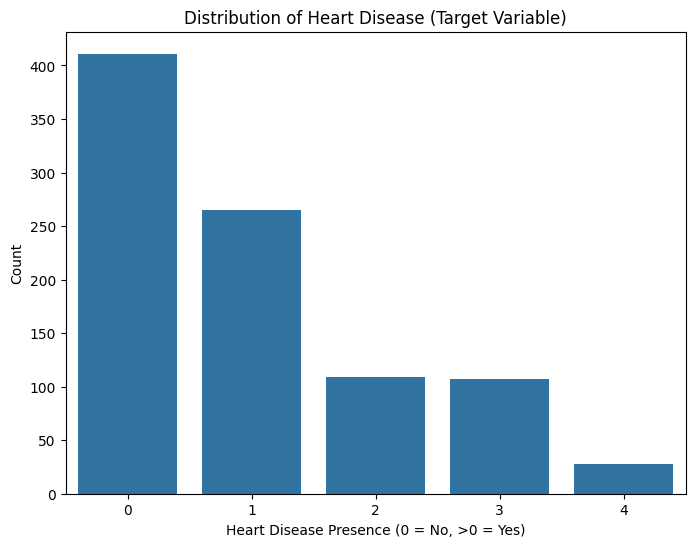


Distribution of binary target variable:


,count
target,
1,509
0,411


In [18]:
# Drop 'id' and 'dataset' columns as they are not relevant for the model
df_eda = df.copy()
df_eda = df_eda.drop(columns=['id', 'dataset'])

print("Dropped 'id' and 'dataset' columns. New DataFrame shape:")
print(df_eda.shape)

# Distribution of the target variable 'num'
plt.figure(figsize=(8, 6))
sns.countplot(x='num', data=df_eda)
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Heart Disease Presence (0 = No, >0 = Yes)')
plt.ylabel('Count')
plt.show()

# Convert 'num' column to binary target: 0 for no disease, 1 for disease
df_eda['target'] = df_eda['num'].apply(lambda x: 1 if x > 0 else 0)
print("\nDistribution of binary target variable:")
display(df_eda['target'].value_counts())

# Drop the original 'num' column
df_eda = df_eda.drop(columns=['num'])


Numerical columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


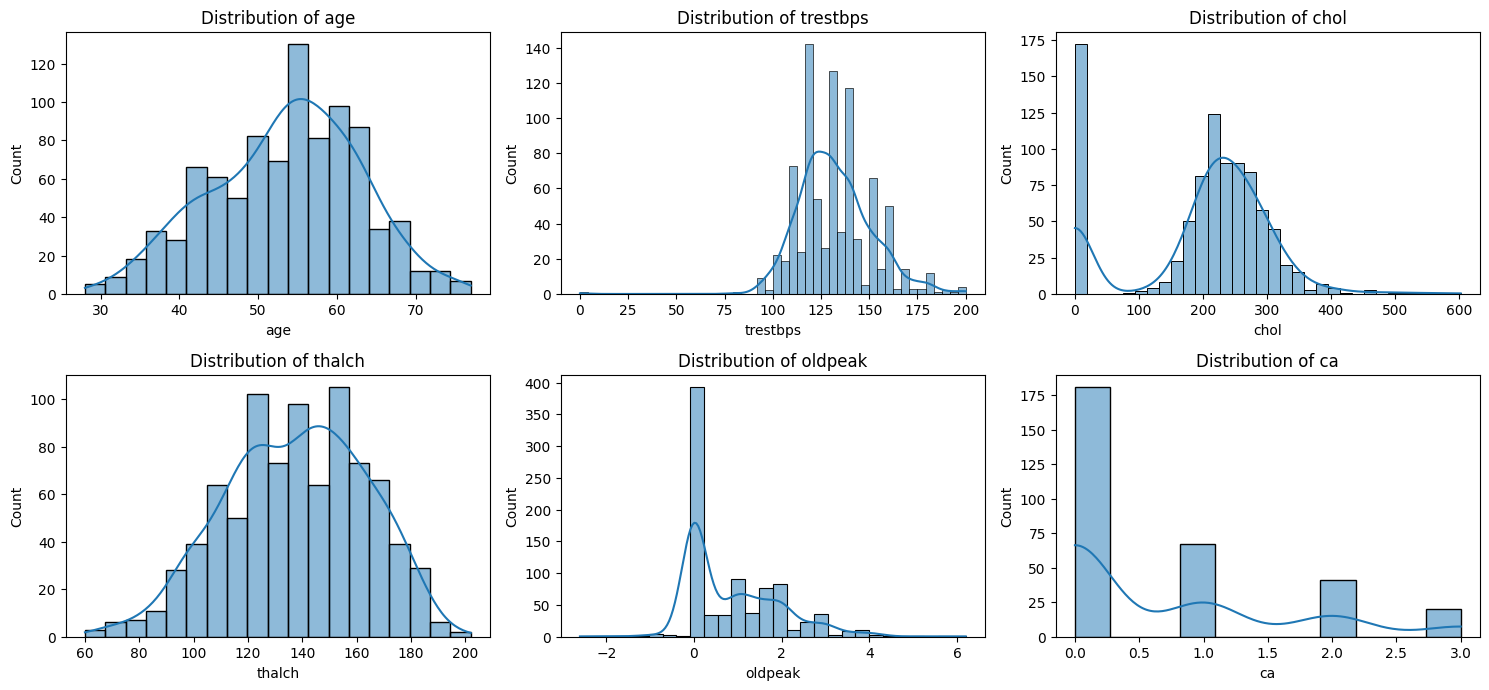

In [19]:
# Visualize distributions of numerical features

# Identify numerical and categorical columns after dropping 'id' and 'dataset'
numerical_cols = df_eda.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_eda.select_dtypes(include='object').columns.tolist()

# Remove 'target' from numerical_cols for now, as we visualize it separately or as part of relationships
if 'target' in numerical_cols:
    numerical_cols.remove('target')

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.histplot(df_eda[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1714/1788448691.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_eda, palette='viridis')
/tmp/ipykernel_1714/1788448691.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_eda, palette='viridis')
/tmp/ipykernel_1714/1788448691.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_eda, palette='viridis')
/tmp/ipykernel_1714/1788448691.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

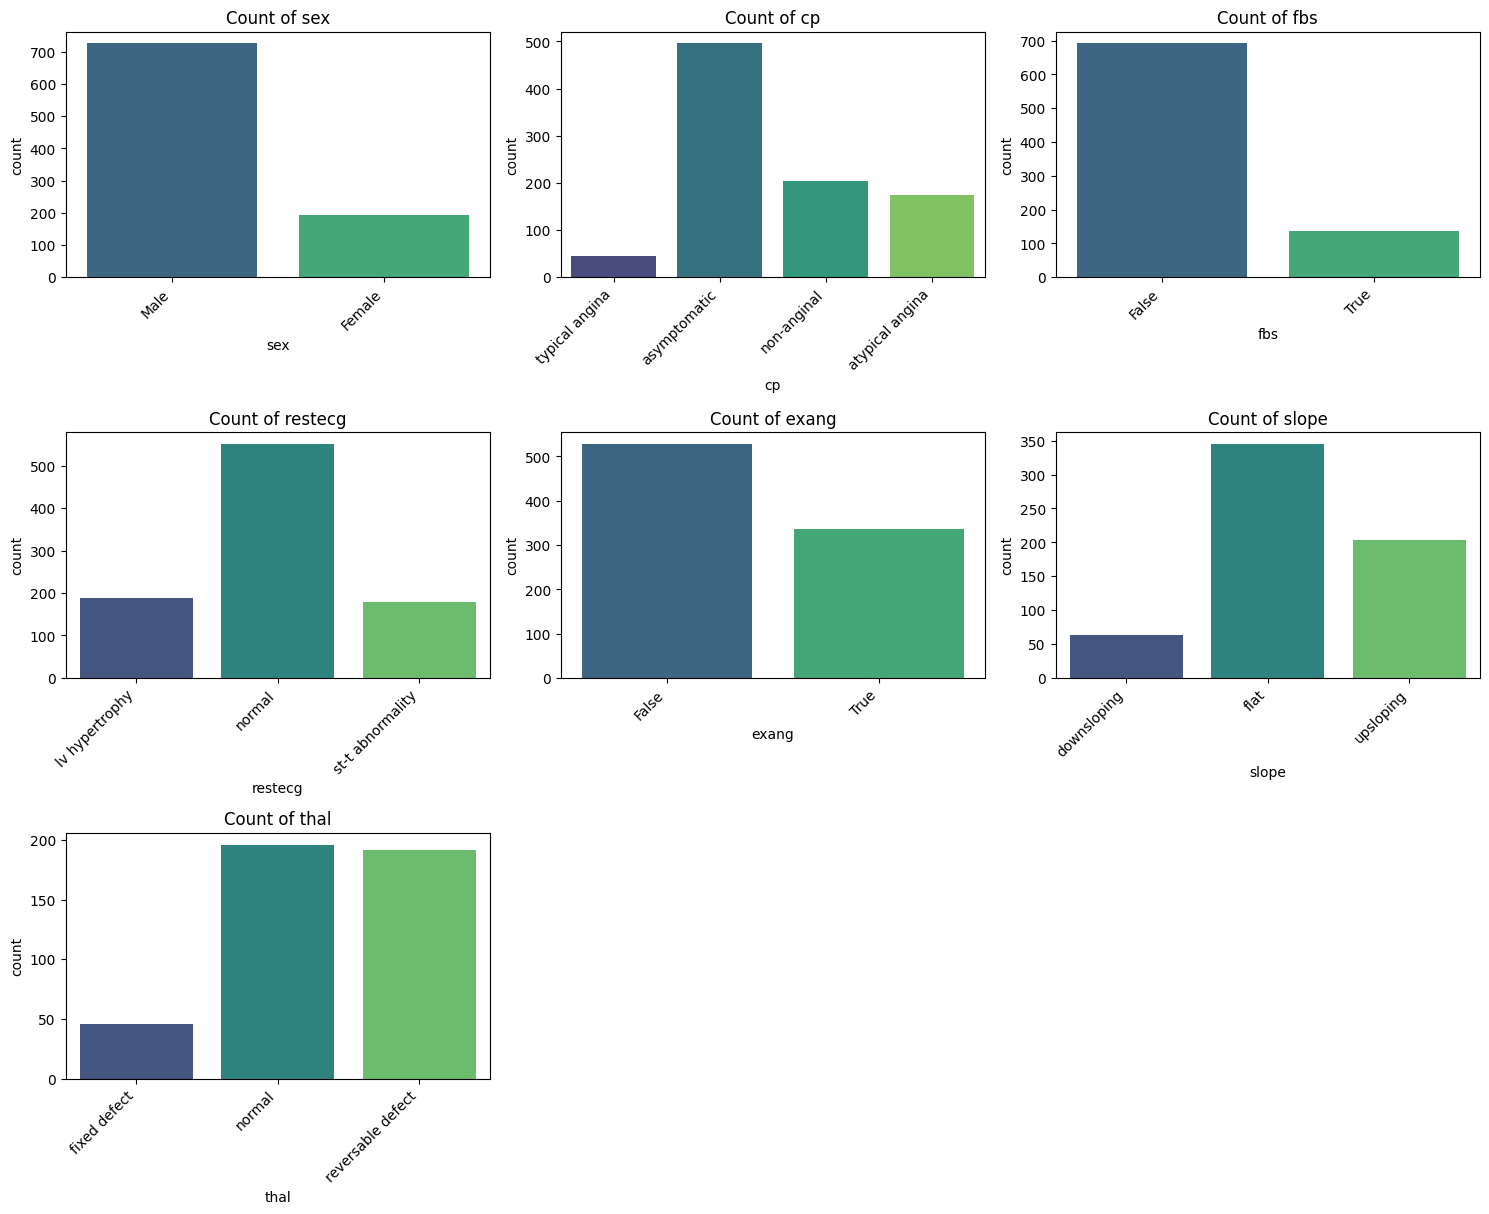

In [20]:
# Visualize count plots for categorical features

plt.figure(figsize=(15, 15))
for i, col in enumerate(categorical_cols):
    plt.subplot(4, 3, i + 1) # Adjust subplot grid based on number of categorical columns
    sns.countplot(x=col, data=df_eda, palette='viridis')
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1.3 Preprocessing Data

In [21]:
# Separate features (X) and target (y)
X = df_eda.drop('target', axis=1)
y = df_eda['target']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of features (X): (920, 13)
Shape of target (y): (920,)

Shape of X_train: (736, 13)
Shape of X_test: (184, 13)
Shape of y_train: (736,)
Shape of y_test: (184,)


In [22]:
# Identify numerical and categorical columns for preprocessing
# Update numerical_cols and categorical_cols based on the current X (features) DataFrame

numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f"Numerical features to preprocess: {numerical_features}")
print(f"Categorical features to preprocess: {categorical_features}")

# Create preprocessing pipelines for numerical and categorical features

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocessing pipeline created successfully.")

Numerical features to preprocess: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical features to preprocess: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Preprocessing pipeline created successfully.


## 2. Model Training

In [23]:
from sklearn.impute import SimpleImputer

# Create the full pipeline with preprocessing and Logistic Regression model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Train the model
model_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 3. Model Evaluation

In [24]:
# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8424
Precision: 0.8411
Recall: 0.8824
F1 Score: 0.8612

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.79      0.82        82
           1       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



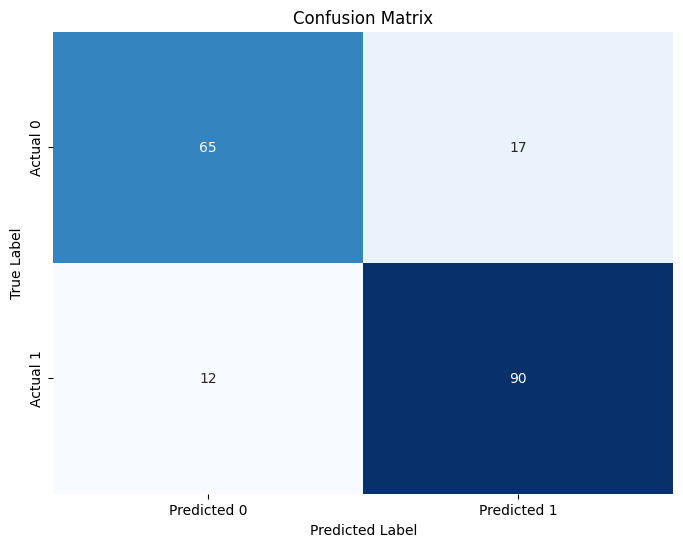

In [25]:
# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Further Data Analysis: Preprocessing and Descriptive Analysis

### 1. Preprocessing: Handling Duplicates and Outliers

#### 1.1 Duplicates

In [26]:
# Check for duplicate rows
duplicates = df_eda.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print("Removing duplicate rows...")
    df_eda.drop_duplicates(inplace=True)
    print(f"Number of rows after removing duplicates: {df_eda.shape[0]}")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 2
Removing duplicate rows...
Number of rows after removing duplicates: 918


#### 1.2 Outliers (using IQR method for numerical features)

In [27]:
print("Identifying and handling outliers for numerical features...")

# Re-identify numerical columns (excluding 'target' if it's there)
numerical_cols_for_outliers = X.select_dtypes(include=np.number).columns.tolist()

for col in numerical_cols_for_outliers:
    Q1 = df_eda[col].quantile(0.25)
    Q3 = df_eda[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers_count = df_eda[(df_eda[col] < lower_bound) | (df_eda[col] > upper_bound)].shape[0]
    print(f"Column '{col}': {outliers_count} outliers detected (outside [{lower_bound:.2f}, {upper_bound:.2f}])")

    # Option to cap outliers (replace with bounds) instead of removal
    df_eda[col] = np.where(df_eda[col] < lower_bound, lower_bound, df_eda[col])
    df_eda[col] = np.where(df_eda[col] > upper_bound, upper_bound, df_eda[col])
    # For this analysis, we will cap the outliers to keep more data points.
    # print(f"  Outliers in '{col}' have been capped to the IQR bounds.")

print("\nOutlier handling (capping) complete for numerical features.")

Identifying and handling outliers for numerical features...
Column 'age': 0 outliers detected (outside [27.50, 79.50])
Column 'trestbps': 28 outliers detected (outside [90.00, 170.00])
Column 'chol': 183 outliers detected (outside [35.50, 407.50])
Column 'thalch': 2 outliers detected (outside [64.50, 212.50])
Column 'oldpeak': 16 outliers detected (outside [-2.25, 3.75])
Column 'ca': 20 outliers detected (outside [-1.50, 2.50])

Outlier handling (capping) complete for numerical features.


### 2. Descriptive Analysis

#### 2.1 Univariate Analysis

##### 2.1.1 Quantitative Variables

Descriptive statistics for quantitative variables:


,count,mean,std,min,25%,50%,75%,max
age,918.0,53.510893,9.432617,28.00,47.0,54.0,60.0,77.00
trestbps,859.0,131.847497,17.479959,90.00,120.0,130.0,140.0,170.00
chol,889.0,205.017435,96.108150,35.50,175.0,223.0,268.0,407.50
thalch,863.0,137.549247,25.916409,64.50,120.0,140.0,157.0,202.00
oldpeak,856.0,0.870561,1.055045,-2.25,0.0,0.5,1.5,3.75
ca,309.0,0.644013,0.860084,0.00,0.0,0.0,1.0,2.50


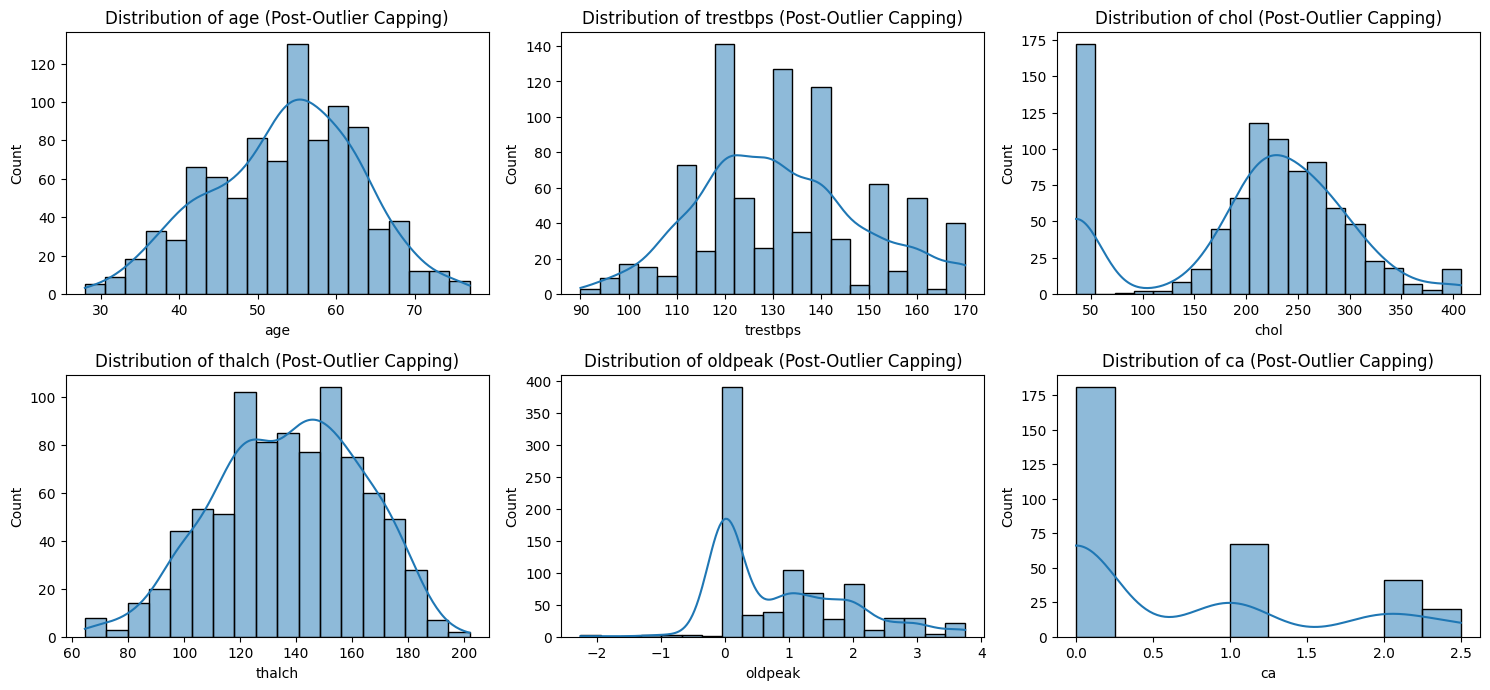

In [28]:
print("Descriptive statistics for quantitative variables:")
display(df_eda[numerical_cols_for_outliers].describe().T)

# Histograms for numerical features (already done in initial EDA, but can be rerun for post-outlier treatment)
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_outliers):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df_eda[col].dropna(), kde=True)
    plt.title(f'Distribution of {col} (Post-Outlier Capping)')
plt.tight_layout()
plt.show()

##### 2.1.2 Qualitative Variables

Frequency tables and bar charts for qualitative variables:

--- sex ---


,count
sex,
Male,725
Female,193


/tmp/ipykernel_1714/3186195173.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_eda, palette='viridis')


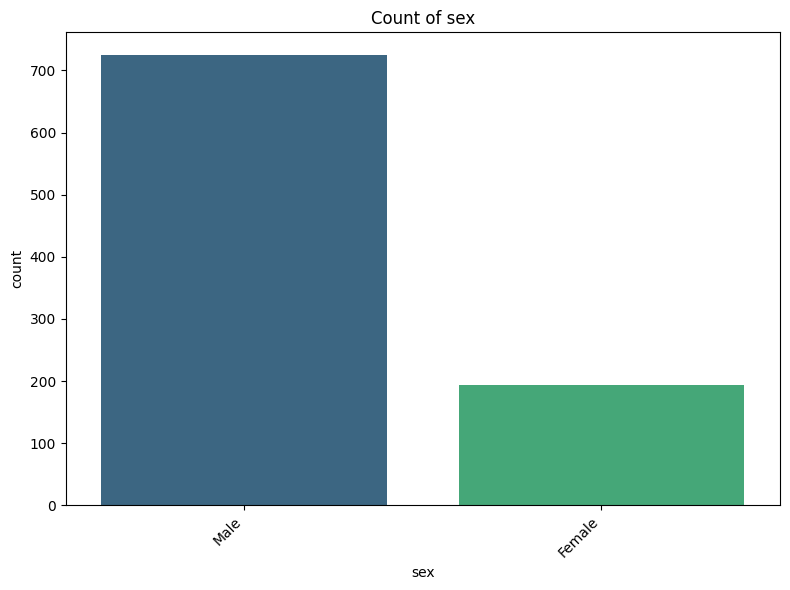


--- cp ---


,count
cp,
asymptomatic,496
non-anginal,203
atypical angina,173
typical angina,46


/tmp/ipykernel_1714/3186195173.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_eda, palette='viridis')


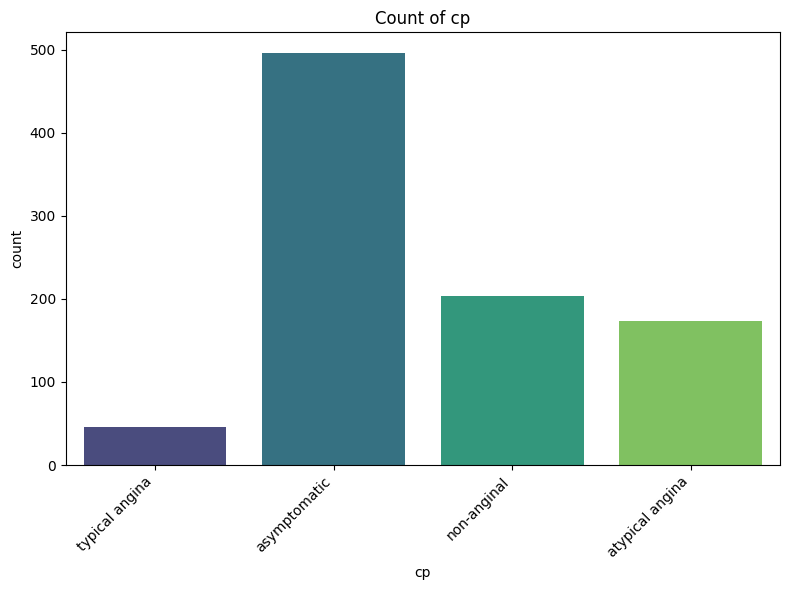


--- fbs ---


,count
fbs,
False,690
True,138


/tmp/ipykernel_1714/3186195173.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_eda, palette='viridis')


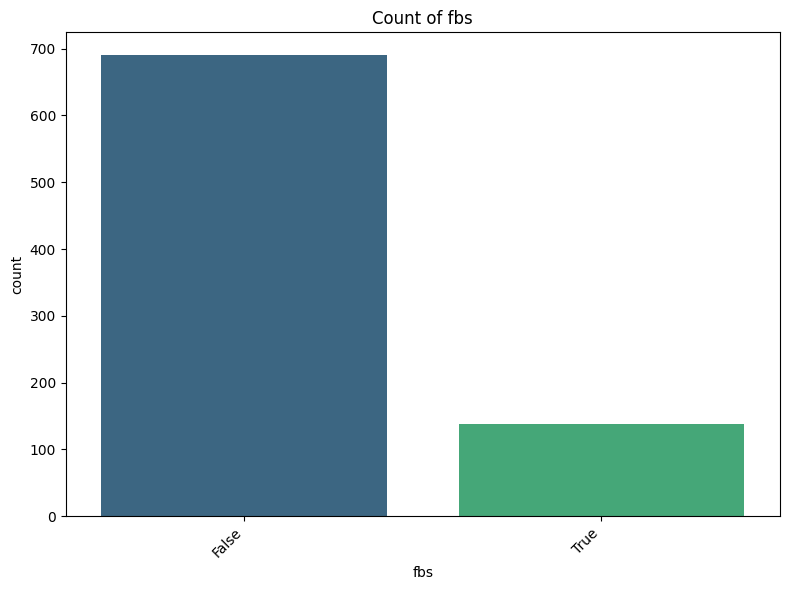


--- restecg ---


,count
restecg,
normal,550
lv hypertrophy,188
st-t abnormality,178


/tmp/ipykernel_1714/3186195173.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_eda, palette='viridis')


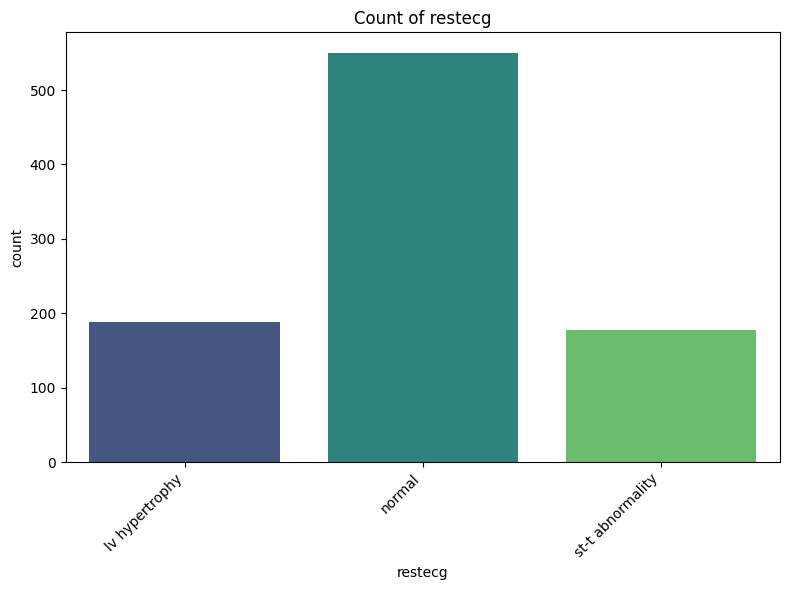


--- exang ---


,count
exang,
False,527
True,336


/tmp/ipykernel_1714/3186195173.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_eda, palette='viridis')


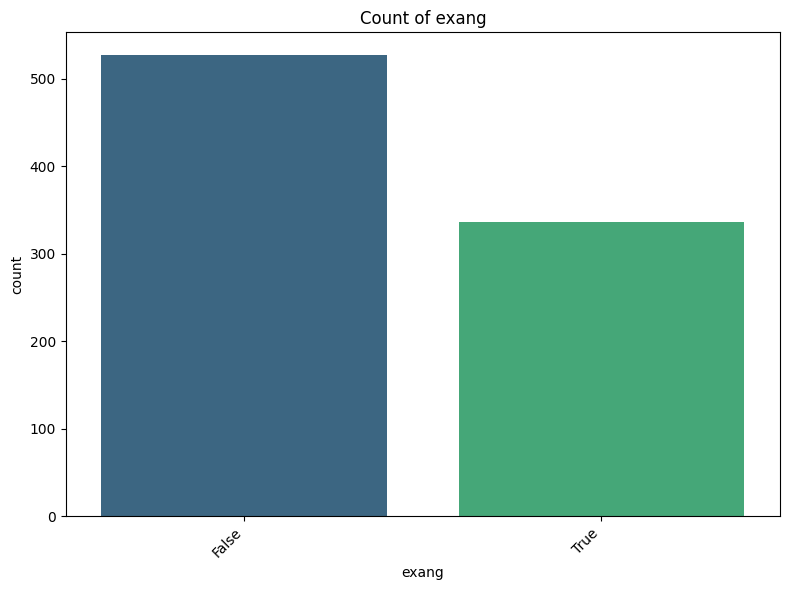


--- slope ---


,count
slope,
flat,345
upsloping,203
downsloping,63


/tmp/ipykernel_1714/3186195173.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_eda, palette='viridis')


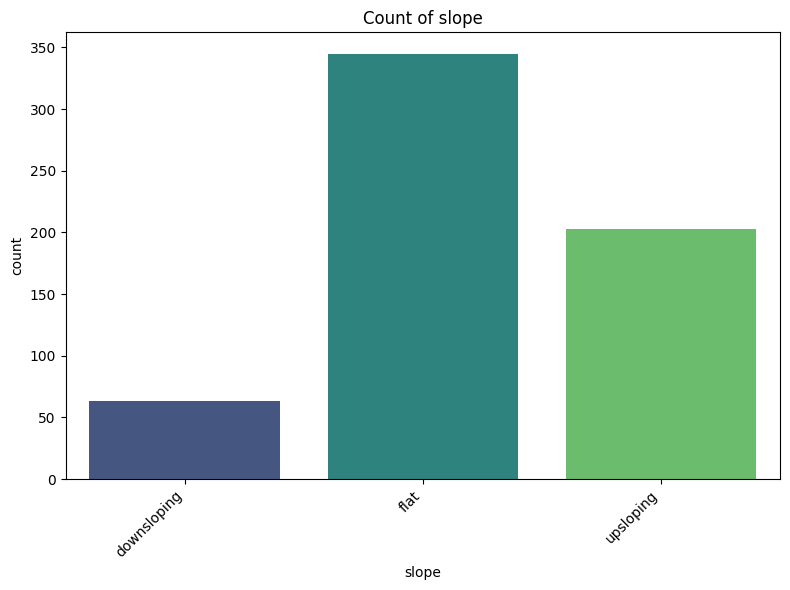


--- thal ---


,count
thal,
normal,196
reversable defect,192
fixed defect,46


/tmp/ipykernel_1714/3186195173.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_eda, palette='viridis')


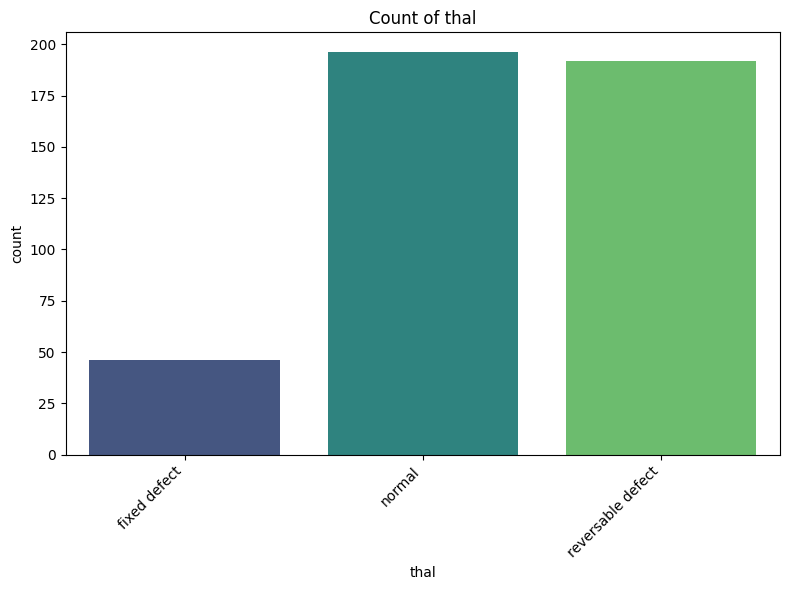

In [29]:
print("Frequency tables and bar charts for qualitative variables:")

for col in categorical_features:
    print(f"\n--- {col} ---")
    display(df_eda[col].value_counts().to_frame())

    # Bar charts for categorical features (already done in initial EDA, but can be re-run)
    plt.figure(figsize=(8, 6))
    sns.countplot(x=col, data=df_eda, palette='viridis')
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

#### 2.2 Bivariate Analysis

##### 2.2.1 Quantitative + Quantitative Variables

Correlation matrix for quantitative variables:


,age,trestbps,chol,thalch,oldpeak,ca
age,1.000000,0.257326,-0.077007,-0.365542,0.262112,0.380861
trestbps,0.257326,1.000000,0.098913,-0.102533,0.171275,0.088881
chol,-0.077007,0.098913,1.000000,0.232056,0.051409,0.060976
thalch,-0.365542,-0.102533,0.232056,1.000000,-0.154863,-0.264085
oldpeak,0.262112,0.171275,0.051409,-0.154863,1.000000,0.275496
ca,0.380861,0.088881,0.060976,-0.264085,0.275496,1.000000


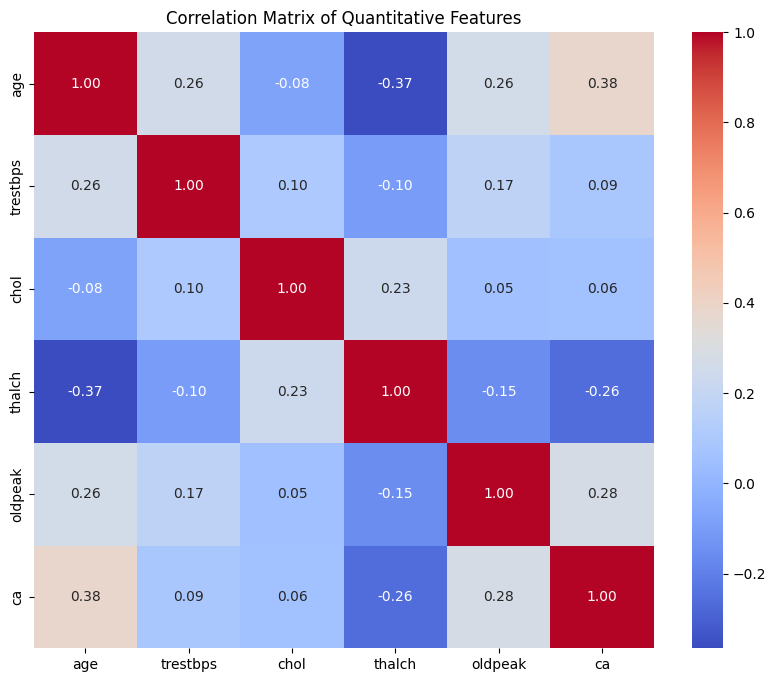

In [30]:
print("Correlation matrix for quantitative variables:")
correlation_matrix = df_eda[numerical_cols_for_outliers].corr()
display(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Quantitative Features')
plt.show()

##### 2.2.2 Quantitative + Qualitative Variables (using target variable for example)

Boxplots of quantitative variables vs. target variable:


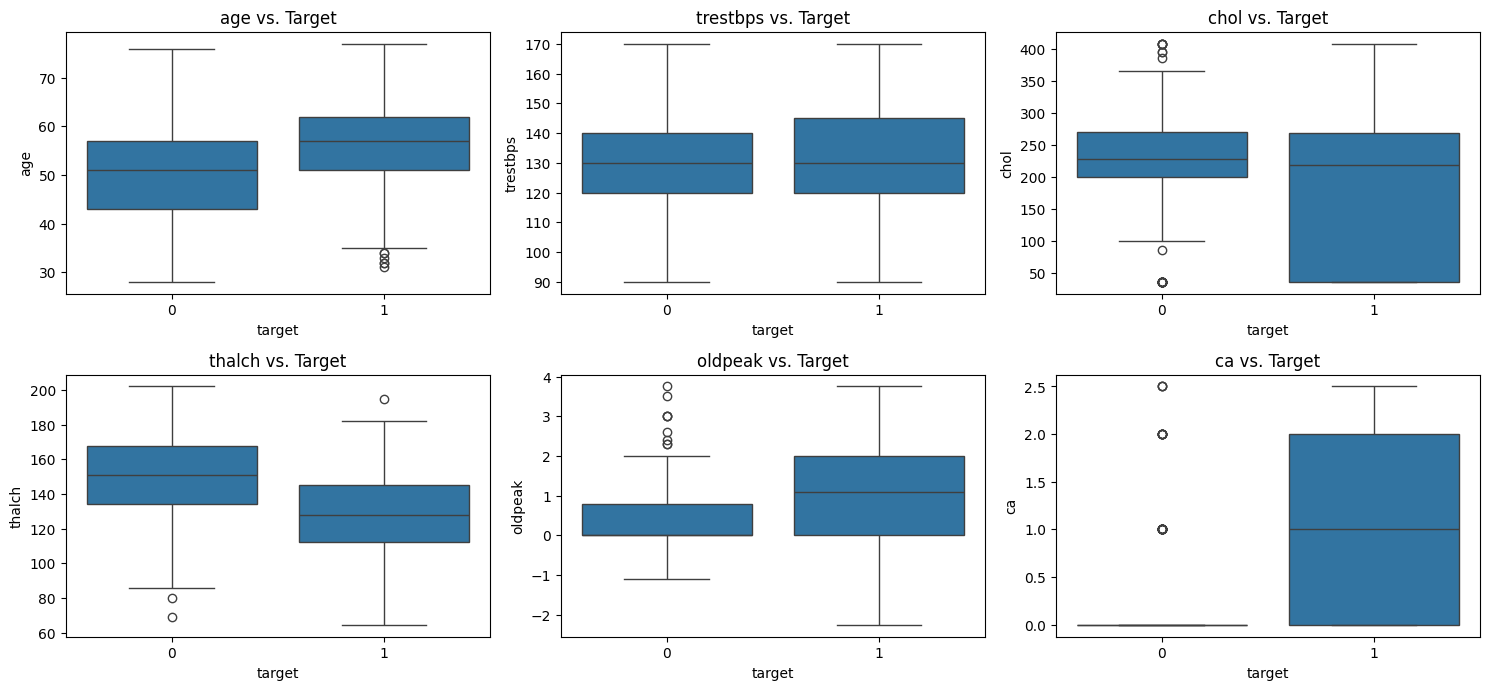

In [31]:
print("Boxplots of quantitative variables vs. target variable:")

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_outliers):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x='target', y=col, data=df_eda)
    plt.title(f'{col} vs. Target')
plt.tight_layout()
plt.show()

##### 2.2.3 Qualitative + Qualitative Variables

Contingency tables, bar plots, Chi-squared test, and Cramer's V for qualitative variables:

--- 'sex' vs 'target' ---


target,0,1
sex,,
Female,143,50
Male,267,458


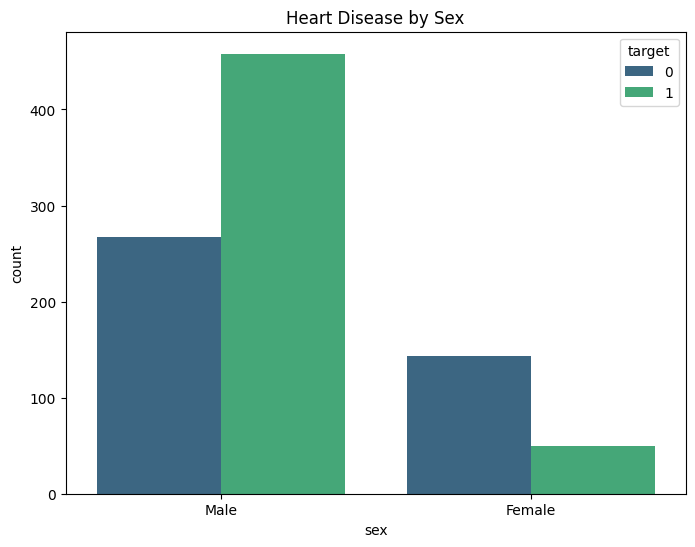

Chi-squared: 84.15, P-value: 0.000, Cramer's V: 0.30

--- 'cp' vs 'target' ---


target,0,1
cp,,
asymptomatic,104,392
atypical angina,149,24
non-anginal,131,72
typical angina,26,20


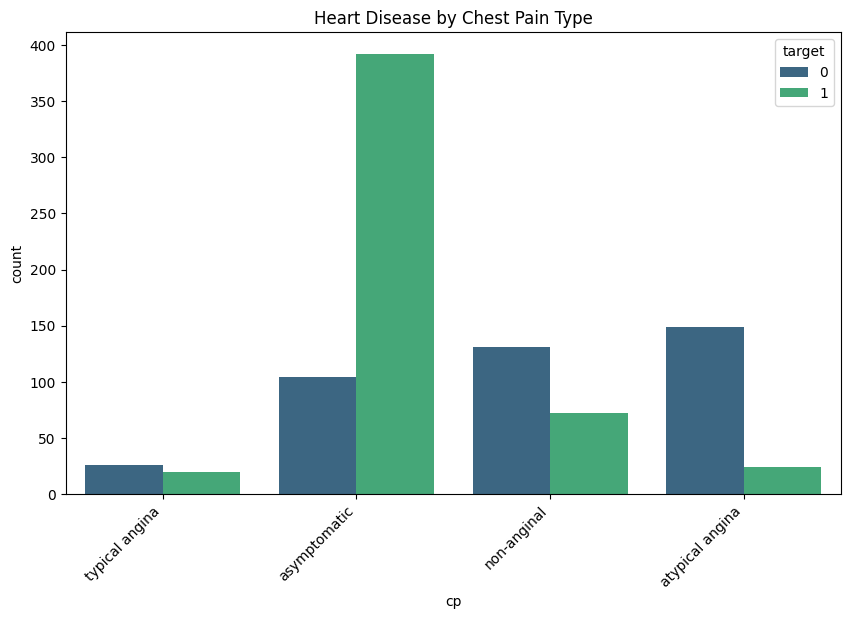

Chi-squared: 268.07, P-value: 0.000, Cramer's V: 0.54


In [32]:
from itertools import combinations
from scipy.stats import chi2_contingency

print("Contingency tables, bar plots, Chi-squared test, and Cramer's V for qualitative variables:")

# Example: 'sex' vs 'target'
print("\n--- 'sex' vs 'target' ---")
contingency_table_sex_target = pd.crosstab(df_eda['sex'], df_eda['target'])
display(contingency_table_sex_target)

plt.figure(figsize=(8, 6))
sns.countplot(x='sex', hue='target', data=df_eda, palette='viridis')
plt.title('Heart Disease by Sex')
plt.show()

chi2, p, _, _ = chi2_contingency(contingency_table_sex_target)
n = contingency_table_sex_target.sum().sum()
k = min(contingency_table_sex_target.shape) - 1
v_cramer = np.sqrt(chi2 / (n * k))
print(f"Chi-squared: {chi2:.2f}, P-value: {p:.3f}, Cramer's V: {v_cramer:.2f}")

# Example: 'cp' (Chest Pain type) vs 'target'
print("\n--- 'cp' vs 'target' ---")
contingency_table_cp_target = pd.crosstab(df_eda['cp'], df_eda['target'])
display(contingency_table_cp_target)

plt.figure(figsize=(10, 6))
sns.countplot(x='cp', hue='target', data=df_eda, palette='viridis')
plt.title('Heart Disease by Chest Pain Type')
plt.xticks(rotation=45, ha='right')
plt.show()

chi2, p, _, _ = chi2_contingency(contingency_table_cp_target)
n = contingency_table_cp_target.sum().sum()
k = min(contingency_table_cp_target.shape) - 1
v_cramer = np.sqrt(chi2 / (n * k))
print(f"Chi-squared: {chi2:.2f}, P-value: {p:.3f}, Cramer's V: {v_cramer:.2f}")

# Note: Due to the number of combinations, only key examples are shown.
# A loop could be used for all combinations if needed.

### 3. Inferential Analysis

In [33]:
print("Inferential analysis was partially covered by Chi-squared tests in the bivariate qualitative analysis.")
print("For a deeper inferential analysis, we would typically perform hypothesis testing on specific relationships ")
print("or build predictive models to infer relationships and make predictions on unseen data.")
print("The Logistic Regression model training and evaluation already serves as a form of inferential analysis for predicting heart disease.")

Inferential analysis was partially covered by Chi-squared tests in the bivariate qualitative analysis.
For a deeper inferential analysis, we would typically perform hypothesis testing on specific relationships 
or build predictive models to infer relationships and make predictions on unseen data.
The Logistic Regression model training and evaluation already serves as a form of inferential analysis for predicting heart disease.
